# Notebook 4 — Sentiment Analysis (Classical → Neural → Transformers → ABSA)

In previous notebooks we built:
- a cleaned Persian text pipeline
- a TF‑IDF doctor retriever

In this notebook, we move to a new task:

> **Sentiment Analysis**: classify each patient review as **Positive / Neutral / Negative**.

We will keep this notebook **teachable** and **self-contained**:
- We only use the dataset exported by previous notebooks.
- We can run everything in a small **Demo Mode** (fast, classroom-friendly).
- The same code can also run on the full project dataset.



## Part 0 — Setup & Data Loading

### Dataset used in this notebook

We load the file produced by the earlier notebooks:

**`comments_for_tfidf_retriever.csv`**

It contains one row per patient review, with these columns:

- `doctor_id`
- `final_preprocessed_text`  (tokenized text, mostly useful for retrieval)
- `text_step04`              (cleaned Persian text, readable, best for sentiment)
- `rate`                     (1–5 stars; *not* a perfect sentiment label)
- `label`                    (raw label from source; may contain placeholder negatives)
- `is_placeholder_negative`  (e.g., text = "عدم رضایت")

### Our sentiment text column

For sentiment modeling we will use:
- **`text_step04`** as the main input text (human-readable, still has sentiment words)

In [19]:
# ----------------------------
# Part 0.2 — Imports
# ----------------------------

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    "figure.figsize": (10, 4),
    "axes.grid": True,
    "grid.alpha": 0.25
})

print("Imports OK")

Imports OK


In [20]:
# ----------------------------
# Part 0.3 — Configuration
# ----------------------------

MODE = "demo"   # "demo" (fast) or "full" (project-scale)
DEMO_N = 2000   # used only in demo mode

DATA_PATH = Path("comments_for_tfidf_retriever.csv")

OUT_DIR = Path("processed_data/notebook04_sentiment")
MODEL_DIR = Path("models/notebook04_sentiment")
OUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"MODE     = {MODE}")
print(f"DEMO_N   = {DEMO_N}")
print(f"DATA     = {DATA_PATH}")
print(f"OUT_DIR  = {OUT_DIR}")
print(f"MODEL_DIR= {MODEL_DIR}")

MODE     = demo
DEMO_N   = 2000
DATA     = comments_for_tfidf_retriever.csv
OUT_DIR  = processed_data\notebook04_sentiment
MODEL_DIR= models\notebook04_sentiment


In [21]:
# ----------------------------
# Part 0.4 — Load the dataset
# ----------------------------

df = pd.read_csv(DATA_PATH, keep_default_na=False)

# Basic type fixes
df["doctor_id"] = df["doctor_id"].astype(str)
df["text_step04"] = df["text_step04"].astype(str)
df["final_preprocessed_text"] = df["final_preprocessed_text"].astype(str)

# Convert rate to numeric (may contain empty strings)
df["rate_num"] = pd.to_numeric(df.get("rate", np.nan), errors="coerce")

# Placeholder negatives (e.g., text="عدم رضایت") are not useful as text supervision
if "is_placeholder_negative" in df.columns:
    col = df["is_placeholder_negative"]

    # Robust boolean parsing (handles True/False, "True"/"False", 1/0, "", etc.)
    if col.dtype != bool:
        df["is_placeholder_negative"] = (
            col.astype(str).str.strip().str.lower()
            .map({"true": True, "false": False, "1": True, "0": False, "": False})
            .fillna(False)
            .astype(bool)
        )
    else:
        df["is_placeholder_negative"] = col

    df = df[~df["is_placeholder_negative"]].copy()

# Remove empty text
df = df[df["text_step04"].str.strip().ne("")].copy()

print(f"Loaded {len(df):,} comments | {df['doctor_id'].nunique():,} doctors")
df.head(3)

Loaded 63,722 comments | 545 doctors


,doctor_id,final_preprocessed_text,text_step04,rate,label,date,tok_all_count,tok_nostop_count,is_placeholder_negative,rate_num
0,100246,حاذق,بسیار حاذق,5.0,1,۱۴۰۳/۰۸/۰۴,2,1,False,5.0
1,100246,زگیل ناخن درمانم,زگیل زیر ناخن تحت درمانم,5.0,1,۱۴۰۰/۰۲/۰۶,5,3,False,5.0
2,100246,درود تشخیص درست خارش بدن ودرمان,درود تشخیص درست خارش بدن ودرمان عالی,5.0,1,۱۴۰۴/۰۹/۲۸,7,6,False,5.0


In [22]:
# ----------------------------
# Part 0.5 — Demo sampling
# ----------------------------

if MODE == "demo":
    df_work = df.sample(n=min(DEMO_N, len(df)), random_state=SEED).copy().reset_index(drop=True)
else:
    df_work = df.copy().reset_index(drop=True)

print(f"Working dataset: {len(df_work):,} rows (MODE={MODE})")
df_work.head(3)

Working dataset: 2,000 rows (MODE=demo)


,doctor_id,final_preprocessed_text,text_step04,rate,label,date,tok_all_count,tok_nostop_count,is_placeholder_negative,rate_num
0,319817,عالی بود,عالی بود,5.0,1,۱۴۰۳/۰۶/۲۴,2,0,False,5.0
1,103130,العاده,فوق العاده,5.0,1,۱۳۹۹/۰۳/۲۵,2,1,False,5.0
2,223843,سنگ کلیه داشتم ویک مشکل پروستات مراجعه,سنگ کلیه داشتم ویک بار هم مشکل پروستات مراجعه ...,5.0,1,۱۴۰۲/۰۸/۱۷,10,7,False,5.0


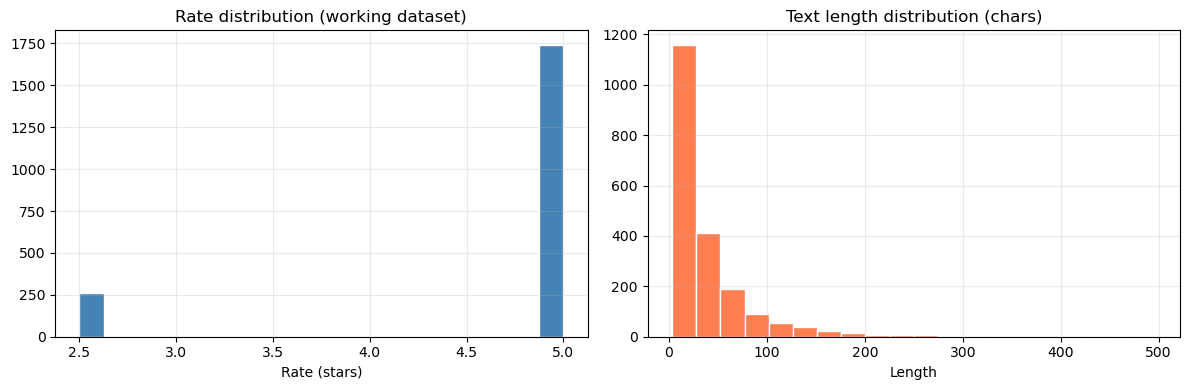

Example texts:
- بسیار با تجربه
- عالی بود
- تنگی کانال نخاع
- ریزش مو داشتم و رفع شد بسیار عالی هستند
- عالی بودن


In [23]:
# ----------------------------
# Part 0.7 — Quick exploration (optional)
# ----------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_work["rate_num"].dropna().hist(bins=20, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Rate distribution (working dataset)")
axes[0].set_xlabel("Rate (stars)")

text_len = df_work["text_step04"].astype(str).str.len()
text_len.hist(bins=20, ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title("Text length distribution (chars)")
axes[1].set_xlabel("Length")

plt.tight_layout()
plt.show()

print("Example texts:")
for t in df_work["text_step04"].sample(5, random_state=SEED).tolist():
    print("-", t[:120])

## Part 1 — Build a Labeled Sentiment Dataset

Models cannot learn sentiment without labeled examples.

In this part we will:
1. Define our sentiment label space (**-1 / 0 / +1**).
2. Create a small labeled dataset in a classroom-friendly way.
3. Save `train/dev/test` splits for the rest of the notebook.

Important note:
- The `rate` (stars) column is **not ground-truth sentiment**.
- We will use it only as a **weak signal** to bootstrap a labeled dataset.

### 1.1 Label space and quick guidelines

We use 3 labels:

- **+1 (Positive)**: clear satisfaction / recommendation
- **0 (Neutral)**: informational, unclear, or mixed sentiment
- **-1 (Negative)**: clear dissatisfaction (including service complaints)

Rules of thumb:
- Service complaints (wait time, secretary, cost, scheduling) count as **negative**
- Purely informational comments (e.g., "MRI written", "prescribed meds") are often **neutral**
- Mixed sentiment ("doctor great but secretary rude") → **neutral**

In [24]:
# ----------------------------
# Part 1.2 — Prepare text column for sentiment
# ----------------------------

df_s = df_work.copy()

# Sentiment input text
df_s["text"] = df_s["text_step04"].astype(str).str.strip()

# Keep only non-empty
df_s = df_s[df_s["text"].ne("")].copy()

print("Working columns:", [c for c in ["doctor_id", "text", "rate_num", "label"] if c in df_s.columns])
df_s[["doctor_id", "rate_num", "text"]].head(5)

Working columns: ['doctor_id', 'text', 'rate_num', 'label']


,doctor_id,rate_num,text
0,319817,5.0,عالی بود
1,103130,5.0,فوق العاده
2,223843,5.0,سنگ کلیه داشتم ویک بار هم مشکل پروستات مراجعه ...
3,323418,2.5,خوب بودنند
4,261269,5.0,من بیمار دکتر بودم


### 1.3 Why not random sampling?

If we randomly sample comments, most labels will be positive (high class imbalance).
That makes training and evaluation confusing in a classroom setting.

So we will build a **balanced bootstrapped dataset**:
- some **likely-positive** examples
- some **likely-negative** examples
- some **likely-neutral** examples

In Demo Mode we keep it small and fast.
In Full Mode we can increase the sample sizes.

In [25]:
# ----------------------------
# Part 1.4 — Build a balanced candidate pool (weak labels)
# Token-based heuristics + stricter service-complaint detection
# ----------------------------

import re

df_s = df.copy()
df_s["text"] = df_s["text_step04"].astype(str).str.strip()
df_s = df_s[df_s["text"].ne("")].copy()

# Simple heuristic tokenization (ONLY for weak labeling)
KW_CLEAN_RE = re.compile(r"[^0-9A-Za-z\u0600-\u06FF]+")
def kw_tokens(text: str):
    t = str(text).lower().replace("\u200c", " ")
    t = KW_CLEAN_RE.sub(" ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t.split() if t else []

def kw_bigrams(toks):
    return list(zip(toks, toks[1:])) if len(toks) >= 2 else []

df_s["kw_toks"] = df_s["text"].apply(kw_tokens)
df_s["kw_bi"]   = df_s["kw_toks"].apply(kw_bigrams)
df_s["n_tokens"] = df_s["kw_toks"].apply(len)

MIN_TOKENS = 3
df_s["too_short"] = df_s["n_tokens"].lt(MIN_TOKENS)

def has_any_token(toks, token_set):
    return len(set(toks) & token_set) > 0

def has_any_phrase(bigrams, phrase_set):
    return len(set(bigrams) & phrase_set) > 0

# -------------------------
# Strong positive cues (small + teachable)
# -------------------------
POS_TOKENS = {"عالی","بهترین","محشر","حاذق","ماهر","کاربلد","دقیق","راضیم","ممنون","مرسی","سپاس","تشکر"}
POS_PHRASES = {
    ("فوق","العاده"),
    ("بی","نظیر"),
    ("تشخیص","دقیق"),
    ("نتیجه","گرفتم"),
    ("بهتر","شدم"),
    ("خوب","شدم"),
    ("خوش","برخورد"),
    ("با","حوصله"),
    ("حل","شد"),
    ("برطرف","شد"),
    ("رضایت","بخش"),
}

# -------------------------
# Strong negative cues (avoid ambiguous tokens like "تاخیر" alone)
# -------------------------
NEG_TOKENS = {"افتضاح","مزخرف","فاجعه","ناراضی","پشیمون","پشیمان","اشتباه","معطلی","انتظار","پولکی","گرون","گران"}
NEG_PHRASES = {
    ("بد","برخورد"),
    ("بی","ادب"),
    ("بی","احترام"),
    ("راضی","نیستم"),
    ("راضی","نبودم"),
    ("توصیه","نمی"),
    ("پیشنهاد","نمی"),
    ("دیگه","نمیرم"),
    ("نتیجه","نگرفتم"),
    ("اثر","نداشت"),
    ("فایده","نداشت"),
    ("بدتر","شدم"),
    ("هزینه","بالا"),
    ("تشخیص","اشتباه"),
    ("دارو","اشتباه"),
    ("حل","نشد"),
    ("حل","نشده"),
    ("فرقی","نکرد"),
    ("تغییر","نکرد"),
    ("بهتر","نشد"),
}

INFO_TOKENS = {"نسخه","دارو","آزمایش","سونو","سونگرافی","تصویربرداری","mri","ct","نوار","عمل","جراحی","لیزر","تزریق"}

# Soft positive cues for mixed detection
SOFT_POS_TOKENS = {"خوب","خوبه","مهربان","منصف","صبور","بااخلاق","خوشبرخورد","حوصله"}
SOFT_POS_PHRASES = {("خوب","بود"), ("خیلی","خوب")}

CONTRAST_TOKENS = {"ولی","اما","هرچند"}

# -------------------------
# Service complaint detection (STRICT): only clear complaint phrases
# This prevents false positives like: "no crowd (was not crowded)".
# -------------------------
SERVICE_COMPLAINT_PHRASES = {
    ("خیلی","شلوغ"),
    ("شلوغ","بود"),
    ("معطلی","زیاد"),
    ("انتظار","زیاد"),
    ("هزینه","بالا"),
    ("دسترسی","سخت"),
    ("تلفن","جواب"),
    ("منشی","بد"),
    ("نوبت","دیر"),
    ("نوبت","دهی"),
}

def strong_pos(row):
    return has_any_token(row["kw_toks"], POS_TOKENS) or has_any_phrase(row["kw_bi"], POS_PHRASES)

def strong_neg(row):
    return has_any_token(row["kw_toks"], NEG_TOKENS) or has_any_phrase(row["kw_bi"], NEG_PHRASES)

def info_hit(row):
    return has_any_token(row["kw_toks"], INFO_TOKENS)

def soft_pos(row):
    return has_any_token(row["kw_toks"], SOFT_POS_TOKENS) or has_any_phrase(row["kw_bi"], SOFT_POS_PHRASES)

def contrast_hit(row):
    return has_any_token(row["kw_toks"], CONTRAST_TOKENS)

def service_complaint(row):
    return has_any_phrase(row["kw_bi"], SERVICE_COMPLAINT_PHRASES)

df_s["has_pos_kw"]  = df_s.apply(strong_pos, axis=1)
df_s["has_neg_kw"]  = df_s.apply(strong_neg, axis=1)
df_s["has_info_kw"] = df_s.apply(info_hit, axis=1)
df_s["has_soft_pos_kw"] = df_s.apply(soft_pos, axis=1)
df_s["has_contrast"] = df_s.apply(contrast_hit, axis=1)
df_s["has_service_complaint"] = df_s.apply(service_complaint, axis=1)

# Mixed = (negative or service complaint) + (positive or soft positive) + contrast word
df_s["mixed_cue"] = (df_s["has_neg_kw"] | df_s["has_service_complaint"]) & (df_s["has_pos_kw"] | df_s["has_soft_pos_kw"]) & df_s["has_contrast"]

# Candidates
pos_cand = df_s[df_s["has_pos_kw"] & ~df_s["has_neg_kw"] & ~df_s["has_service_complaint"] & ~df_s["too_short"]].copy()

neg_cand = df_s[
    (df_s["has_neg_kw"] | df_s["has_service_complaint"] | df_s["rate_num"].le(1.8))
    & ~df_s["has_pos_kw"]
    & ~df_s["too_short"]
    & ~df_s["mixed_cue"]
].copy()

neu_cand = df_s[
    (df_s["mixed_cue"])
    | (df_s["has_info_kw"] & ~df_s["has_pos_kw"] & ~df_s["has_neg_kw"])
    | (df_s["too_short"] & ~df_s["has_pos_kw"] & ~df_s["has_neg_kw"])
    | (~df_s["has_pos_kw"] & ~df_s["has_neg_kw"])
].copy()

print("Candidate availability (before sampling):")
print("  pos_cand:", len(pos_cand))
print("  neg_cand:", len(neg_cand))
print("  neu_cand:", len(neu_cand))

# Targets
if MODE == "demo":
    N_POS, N_NEG, N_NEU = 250, 250, 250
else:
    N_POS, N_NEG, N_NEU = 3000, 3000, 3000

pos_pool = pos_cand.sample(n=min(N_POS, len(pos_cand)), random_state=SEED).copy()
neg_pool = neg_cand.sample(n=min(N_NEG, len(neg_cand)), random_state=SEED).copy()
neu_pool = neu_cand.sample(n=min(N_NEU, len(neu_cand)), random_state=SEED).copy()

pos_pool["weak_label"] = 1
neg_pool["weak_label"] = -1
neu_pool["weak_label"] = 0

pos_pool["label_source"] = "weak_pos"
neg_pool["label_source"] = "weak_neg"
neu_pool["label_source"] = "weak_neu"

pool = pd.concat([pos_pool, neg_pool, neu_pool], ignore_index=True)
pool = pool.drop_duplicates(subset=["text"]).reset_index(drop=True)
pool["item_id"] = [f"sent_{i:06d}" for i in range(len(pool))]

print("\nFinal candidate pool:")
print("  size:", len(pool))
print(pool["weak_label"].value_counts().sort_index())

print("\nSamples per class:")
for lbl in [-1, 0, 1]:
    ex = pool[pool["weak_label"] == lbl].sample(3, random_state=SEED)[["rate_num", "text"]]
    print(f"\nLabel {lbl}:")
    for r in ex.to_dict("records"):
        print(" -", f"(rate={r['rate_num']})", r["text"][:120])

pool[["item_id","doctor_id","rate_num","weak_label","label_source","text"]].head(10)

Candidate availability (before sampling):
  pos_cand: 18502
  neg_cand: 408
  neu_cand: 39180

Final candidate pool:
  size: 704
weak_label
-1    226
 0    230
 1    248
Name: count, dtype: int64

Samples per class:

Label -1:
 - (rate=2.5) زیادی معطلی داره کلا شلوغه و منشی‌ها خیلی زیادن و عامل بی نظمی هستن
 - (rate=2.5) یکبار ویزیت تلفنی شدم و از رفتار منشی‌اش راضی نبودم
 - (rate=2.5) مطب خیلی شلوغ بود ماهم شنیدیم کارش خوبه فعلا که تا mri گرفتن پیش رفتیم

Label 0:
 - (rate=5.0) دکتر بابایی جراح دست و کتف بنده بودن و از اون زمان من در خدمتشون بودم بو الان همم برای معاینه‌های دوره‌ای پیششون میرم
 - (rate=2.5) بد نیست
 - (rate=5.0) تنگی نخاع

Label 1:
 - (rate=2.5) حساسیت داشتم خوب شدم
 - (rate=5.0) بسیار عالی منتها به علت کرونا درمان کامل نبود
 - (rate=5.0) عالی بود همچی


,item_id,doctor_id,rate_num,weak_label,label_source,text
0,sent_000000,121861,5.0,1,weak_pos,دکتر کاربلد و دقیق و دلسوز هستند و پیش ایشون ن...
1,sent_000001,227381,5.0,1,weak_pos,ایشان بسیار حاذق می‌باشند سال 95 به همراه دکتر...
2,sent_000002,253573,5.0,1,weak_pos,حاذق و خوش‌رو
3,sent_000003,114729,5.0,1,weak_pos,دکتر بسیار خوش‌اخلاق ارام و با حوصله هستند و ر...
4,sent_000004,219108,5.0,1,weak_pos,فوق‌العاده مجرب و بااخلاق هستند
5,sent_000005,277071,5.0,1,weak_pos,مشکلاتمونو داشتم دست ایشون درد نکنه خیلی زود ج...
6,sent_000006,115698,5.0,1,weak_pos,بسیار عالی منتها به علت کرونا درمان کامل نبود
7,sent_000007,207435,5.0,1,weak_pos,نتیجه بسیار عالی
8,sent_000008,188603,5.0,1,weak_pos,پزشک بسیار حاذق و با توجه و دقت فراوان نسبت به...
9,sent_000009,127062,5.0,1,weak_pos,دکتر خوب با رفتار مناسب و تشخیص عالی


### 1.5 Optional: LLM labeling (batch mode)

Weak labels are useful, but noisy.

Optionally, we can ask an LLM to label a small subset of items.
To keep cost low:
- label only a limited number of items
- send many comments per request (batching)
- if API key is empty, skip this step and keep weak labels

In [26]:
pip install openai

Note: you may need to restart the kernel to use updated packages.


In [27]:
# ----------------------------
# Part 1.6 — LLM labeling (batched)
# ----------------------------

import json
import pandas as pd

# Hard-coded config (as requested)
USE_LLM  = True
API_KEY  = "sk-Zq0gCt5vWjMD9pSfOtrlmlZV0O11dFru1fycyh8BWPgB604B"                 # <-- put your key here
BASE_URL = "https://api.gapgpt.app/v1"     # <-- your proxy base URL
MODEL    = "gpt-4o-mini"

# Cost controls
LLM_MAX_ITEMS  = len(pool) if MODE == "demo" else 2000
BATCH_SIZE     = 30     # fewer requests; reduce to 30 if you get timeouts
TEXT_MAX_CHARS = 350    # reduce to 200 if timeouts happen

# Recommended: only label the weak -1 and 0 classes (saves money)
LLM_TARGET_WEAK_LABELS = [-1, 0 , 1]

# Build client
from openai import OpenAI
client = OpenAI(api_key=API_KEY, base_url=BASE_URL)

SYSTEM_PROMPT = """You are a professional Persian sentiment annotator.
Label each review:
1 = Positive, 0 = Neutral/Mixed/Informational, -1 = Negative.
Service complaints (wait time, secretary, scheduling, cost) are Negative.

Return ONLY a JSON array (no extra text).
Each item:
{"item_id":"...","label":-1|0|1}
"""

def parse_json_array(s: str):
    """Minimal robust parser: direct json or slice between [ ... ]."""
    s = (s or "").strip()
    try:
        obj = json.loads(s)
        if isinstance(obj, list):
            return obj
    except Exception:
        pass
    i, j = s.find("["), s.rfind("]")
    if i != -1 and j != -1 and j > i:
        obj = json.loads(s[i:j+1])
        if isinstance(obj, list):
            return obj
    raise ValueError("Could not parse a JSON array from the model output.")

def llm_label_batch(items):
    payload = [{"item_id": it["item_id"], "text": it["text"][:TEXT_MAX_CHARS]} for it in items]
    user_prompt = json.dumps(payload, ensure_ascii=False)

    resp = client.chat.completions.create(
        model=MODEL,
        temperature=0,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": user_prompt},
        ],
        max_tokens=2000,
        timeout=90,
    )
    raw = resp.choices[0].message.content or ""
    return parse_json_array(raw)

# Select which rows we send to the LLM (keep this dataframe for QA)
to_label_df = pool[pool["weak_label"].isin(LLM_TARGET_WEAK_LABELS)].copy()
to_label_df = to_label_df.sample(frac=1.0, random_state=SEED).head(min(LLM_MAX_ITEMS, len(to_label_df)))

items = to_label_df[["item_id", "text"]].to_dict("records")
print(f"LLM labeling {len(items)} items in batches of {BATCH_SIZE}...")

all_rows = []
n_batches = (len(items) + BATCH_SIZE - 1) // BATCH_SIZE

for bi in range(n_batches):
    batch = items[bi*BATCH_SIZE : (bi+1)*BATCH_SIZE]
    out = llm_label_batch(batch)

    # Validate: keep only correct schema + correct ids + correct labels
    wanted_ids = {x["item_id"] for x in batch}
    kept_this_batch = 0

    for obj in out:
        if not isinstance(obj, dict):
            continue
        iid = str(obj.get("item_id", ""))
        lab = obj.get("label", None)
        if iid in wanted_ids and lab in (-1, 0, 1):
            all_rows.append({"item_id": iid, "label_llm": int(lab)})
            kept_this_batch += 1

    print(f"Batch {bi+1}/{n_batches} OK  (returned={len(out)} items, kept_in_batch={kept_this_batch}, kept_total={len(all_rows)})")

llm_labels_df = pd.DataFrame(all_rows).drop_duplicates("item_id").reset_index(drop=True)

print("\nLLM labeled items:", len(llm_labels_df))
if len(llm_labels_df):
    print(llm_labels_df["label_llm"].value_counts().sort_index())

LLM labeling 704 items in batches of 30...
Batch 1/24 OK  (returned=30 items, kept_in_batch=30, kept_total=30)
Batch 2/24 OK  (returned=30 items, kept_in_batch=30, kept_total=60)
Batch 3/24 OK  (returned=30 items, kept_in_batch=30, kept_total=90)
Batch 4/24 OK  (returned=30 items, kept_in_batch=30, kept_total=120)
Batch 5/24 OK  (returned=30 items, kept_in_batch=30, kept_total=150)
Batch 6/24 OK  (returned=30 items, kept_in_batch=30, kept_total=180)
Batch 7/24 OK  (returned=30 items, kept_in_batch=30, kept_total=210)
Batch 8/24 OK  (returned=30 items, kept_in_batch=30, kept_total=240)
Batch 9/24 OK  (returned=30 items, kept_in_batch=30, kept_total=270)
Batch 10/24 OK  (returned=30 items, kept_in_batch=30, kept_total=300)
Batch 11/24 OK  (returned=30 items, kept_in_batch=30, kept_total=330)
Batch 12/24 OK  (returned=30 items, kept_in_batch=30, kept_total=360)
Batch 13/24 OK  (returned=30 items, kept_in_batch=30, kept_total=390)
Batch 14/24 OK  (returned=29 items, kept_in_batch=29, kept_

### 1.6.1 QA: Validate LLM outputs (must pass before merging)

Before merging LLM labels into our dataset, we validate:

- schema correctness (`item_id`, `label_llm`)
- label range is valid (-1/0/1)
- no duplicate `item_id`
- 100% coverage (every requested item was labeled)
- no extra IDs returned by the LLM

In [28]:
# ----------------------------
# QA — Validate LLM outputs (non-fatal for tiny missing counts)
# ----------------------------

required_cols = {"item_id", "label_llm"}
assert required_cols.issubset(set(llm_labels_df.columns)), "LLM output missing required columns."

assert llm_labels_df["item_id"].isna().sum() == 0, "NaN item_id in llm_labels_df."
assert llm_labels_df["item_id"].duplicated().sum() == 0, "Duplicate item_id in llm_labels_df."
assert llm_labels_df["label_llm"].isna().sum() == 0, "NaN label_llm in llm_labels_df."
assert set(llm_labels_df["label_llm"].unique()).issubset({-1, 0, 1}), "Invalid label outside {-1,0,1}."

requested_ids = set(to_label_df["item_id"])
got_ids = set(llm_labels_df["item_id"])
missing_ids = sorted(requested_ids - got_ids)
extra_ids = sorted(got_ids - requested_ids)

print("Requested items:", len(requested_ids))
print("LLM returned   :", len(got_ids))
print("Coverage       :", f"{len(got_ids)/max(1,len(requested_ids))*100:.2f}%")
print("Missing IDs    :", len(missing_ids))
print("Extra IDs      :", len(extra_ids))

if missing_ids:
    print("Missing (first 10):", missing_ids[:10])

# We allow a very small number of missing IDs, because merge will fall back to weak labels.
assert len(extra_ids) == 0, "LLM returned extra unknown IDs (should be 0)."
print("QA passed ✓ (missing IDs, if any, will fall back to weak labels in merge)")

Requested items: 704
LLM returned   : 703
Coverage       : 99.86%
Missing IDs    : 1
Extra IDs      : 0
Missing (first 10): ['sent_000552']
QA passed ✓ (missing IDs, if any, will fall back to weak labels in merge)


### 1.6.2 QA: Weak labels vs LLM labels (quick audit)

We compare weak labels to LLM labels to understand:
- how noisy our weak heuristics are
- what kinds of examples get corrected by the LLM

In [29]:
# ----------------------------
# QA — Weak vs LLM audit
# ----------------------------

audit_df = to_label_df[["item_id", "weak_label", "text", "rate_num"]].merge(
    llm_labels_df, on="item_id", how="inner", validate="one_to_one"
)

audit_df["changed"] = (audit_df["weak_label"] != audit_df["label_llm"])

print("Disagreement rate:",
      f"{audit_df['changed'].mean()*100:.1f}%  ({audit_df['changed'].sum()}/{len(audit_df)})")

print("\nConfusion (weak → llm):")
print(pd.crosstab(audit_df["weak_label"], audit_df["label_llm"]))

# Show a few examples of flips (for teaching)
flips = audit_df[audit_df["changed"]].copy()

print("\nExamples: weak=-1 but llm=+1")
ex = flips[(flips["weak_label"] == -1) & (flips["label_llm"] == 1)].head(10)
for r in ex.to_dict("records"):
    print("-", r["text"][:160])

print("\nExamples: weak=0 but llm=-1")
ex = flips[(flips["weak_label"] == 0) & (flips["label_llm"] == -1)].head(10)
for r in ex.to_dict("records"):
    print("-", r["text"][:160])

Disagreement rate: 31.3%  (220/703)

Confusion (weak → llm):
label_llm    -1    0    1
weak_label               
-1          130   58   38
 0           13  107  109
 1            1    1  246

Examples: weak=-1 but llm=+1
- ایشون دکتر با دقت و خوش برخوردی هستند من براس چکاب خدمتشون میرم و بطور کامل راجع به بیماری و شرایط توضیح میدن و همینطور همه کارها در مطب با نظم و بدون معطلی زیا
- تشخیص درست داشتن خیلی دقیقاند مطب بهشتی خیلی شلوغ بود اما آخرین بار مطب ظفر رفتم سرتایم ویزیت شدم
- سرگیجه داشتم دکترباخلاق و حاذقی است معطلی نداشتم چند نفر از بستگان هم توسط ایشان معالجه شدند راضی بودند و دکتر ناصحی را به من معرفی کردند
- صورتم خیلی جوش می‌زد و مدت طولانی درمان‌های مختلف انجام دادم نتیجه نگرفتم الان تقریبا 4 ماهه تحت درمان خانم دکتر گنجه‌ای هستم و نه‌تنها جوش‌ها درمان شدن بلکه مش
- وااقعا دکتر خوبیه نه داروی گرون داد نه نسخه‌ی الکی تجویز کرد برای شکاف گوشه‌ی لبم رفتم پیشش
- بثورات پوستی دوتا دکتر تشخیص اشتباه دادن ایشون تشخیص ویروس دادن و گفتن خودش خوب میشه و رو به بهبودم هستم
- مادرمن 2 س

### 1.6.3 Sanity check: LLM negatives with high star ratings

Stars are not perfect sentiment labels.
We quickly inspect a few cases where `rate` is high but the LLM predicts Negative.

In [30]:
audit_llm = to_label_df[["item_id", "text", "rate_num", "weak_label"]].merge(
    llm_labels_df, on="item_id", how="inner", validate="one_to_one"
)

high_rate_neg = audit_llm[(audit_llm["rate_num"] >= 4.5) & (audit_llm["label_llm"] == -1)].head(10)

print("High-rate but LLM-negative examples:", len(high_rate_neg))
for r in high_rate_neg.to_dict("records"):
    print("-", f"(rate={r['rate_num']})", r["text"][:170])

High-rate but LLM-negative examples: 10
- (rate=5.0) دکتر خوبی بودند منتها مبلغ 50 هزار تومان زمان نوبت دهی آن لاین به ما برگردانده نشد ویزیت دکتر 600 بود برای ما شد 650
- (rate=5.0) بسیار دکتر دقیقی هستن ولی خیلی شلوغن و معطلی زیاد داره مطبشون
- (rate=5.0) دکتر بسیار متخصص و کاربلدی هستند تنها مشکلم وقت چند ساعته و طولانی انتظار در مطب علیرغم داشتن وقت قبلی هست
- (rate=5.0) دکتر محترم و خوش برخوردی بودن من برای روتین‌های پوستی رفتم و اصلا راضی نیستم صورتم لک شده
- (rate=5.0) تشخیص درست و به موقع جراحی مچ پا سالن انتظار تهویه مطبوع نداشت تو فصل گرما اذیت شدیم
- (rate=5.0) هم تشخیص هم رفتار فقط زمان معطلی زیاد بود
- (rate=5.0) با سلام بسیار دکتر باسواد و دقیقی می‌باشد ولی نوبت دهی به شدت ضعیف و حیرانی مریض بالا می‌باشد
- (rate=5.0) دکتر خوبی هستند و بسیار با اخلاق فقط به دلیل زیاد بودن تعداد بیماران مدت زمان انتظار در مطب خیلی زیاد است
- (rate=5.0) بادقت به حرف‌های بیمار گوش می‌دهند ولی به شدت مطب شلوغ هست و وقت دهی بی معنی هست یک ساعت ونیم انتظار
- (rate=5.0) از لحاظ نوبت دهی مطب خیلی 

### 1.7 Merge labels (LLM overrides weak labels)

We now create the final label for each item:

- If an LLM label exists → use it
- Otherwise → fall back to the weak label

We keep both weak and LLM labels for auditability.

In [31]:
# ----------------------------
# Part 1.7 — Merge labels (LLM overrides weak)
# ----------------------------

df_labeled = pool[["item_id", "doctor_id", "rate_num", "text", "weak_label", "label_source"]].copy()

df_labeled = df_labeled.merge(
    llm_labels_df,  # columns: item_id, label_llm
    on="item_id",
    how="left",
    validate="one_to_one",
)

# Final label
df_labeled["label_int"] = df_labeled["label_llm"].fillna(df_labeled["weak_label"]).astype(int)

# Track label source
df_labeled["label_source"] = np.where(df_labeled["label_llm"].notna(), "llm", df_labeled["label_source"])

# Final sanity checks
assert df_labeled["label_int"].isin([-1, 0, 1]).all()
assert df_labeled["label_int"].isna().sum() == 0

print("Final label distribution:")
print(df_labeled["label_int"].value_counts().sort_index())

print("\nLabel source distribution:")
print(df_labeled["label_source"].value_counts())

df_labeled.head(10)

Final label distribution:
label_int
-1    144
 0    167
 1    393
Name: count, dtype: int64

Label source distribution:
label_source
llm         703
weak_neu      1
Name: count, dtype: int64


,item_id,doctor_id,rate_num,text,weak_label,label_source,label_llm,label_int
0,sent_000000,121861,5.0,دکتر کاربلد و دقیق و دلسوز هستند و پیش ایشون ن...,1,llm,1.0,1
1,sent_000001,227381,5.0,ایشان بسیار حاذق می‌باشند سال 95 به همراه دکتر...,1,llm,1.0,1
2,sent_000002,253573,5.0,حاذق و خوش‌رو,1,llm,1.0,1
3,sent_000003,114729,5.0,دکتر بسیار خوش‌اخلاق ارام و با حوصله هستند و ر...,1,llm,1.0,1
4,sent_000004,219108,5.0,فوق‌العاده مجرب و بااخلاق هستند,1,llm,1.0,1
5,sent_000005,277071,5.0,مشکلاتمونو داشتم دست ایشون درد نکنه خیلی زود ج...,1,llm,1.0,1
6,sent_000006,115698,5.0,بسیار عالی منتها به علت کرونا درمان کامل نبود,1,llm,0.0,0
7,sent_000007,207435,5.0,نتیجه بسیار عالی,1,llm,1.0,1
8,sent_000008,188603,5.0,پزشک بسیار حاذق و با توجه و دقت فراوان نسبت به...,1,llm,1.0,1
9,sent_000009,127062,5.0,دکتر خوب با رفتار مناسب و تشخیص عالی,1,llm,1.0,1


In [32]:
# ----------------------------
# Optional: quick inspection
# ----------------------------

for lbl in [-1, 0, 1]:
    print(f"\nExamples for final label {lbl}:")
    ex = df_labeled[df_labeled["label_int"] == lbl].sample(5, random_state=SEED)[["rate_num", "label_source", "text"]]
    for r in ex.to_dict("records"):
        print("-", f"(rate={r['rate_num']}, src={r['label_source']})", r["text"][:160])


Examples for final label -1:
- (rate=2.5, src=llm) مطب بسیار شلوغه نحوه نوبت دهی کاملا غلط هستش خانم‌های باردار هم کنار افراد معمولی بابد 5 ساعت منتظر نوبتشون بشن
- (rate=2.5, src=llm) بیشتر از ظرفیت پذیرش می‌کنند و معطلی بسیار زیاده
- (rate=2.5, src=llm) فعلا تحت درمان 4 ماهه نتیجه نگرفتم هنوز
- (rate=5.0, src=llm) دکتر بسیار حاذقی هستن فقط زمان انتظار ویزیت بیش از اندازه خسته‌کننده است
- (rate=2.5, src=llm) با اینکه از قبل زمان ویزیت مشخص بود بازهم حدود دو ساعت معطل شدم و خیلی هم از ویزیت راضی نبودم

Examples for final label 0:
- (rate=5.0, src=llm) مریض ایشان هستم در رابطه با مشکلی که به تازگی برایم پیش‌آمده سوال دارم
- (rate=5.0, src=llm) برای عمل لوزه سوم دخترم مراجعه کردم قراراست عمل بشه دخترم
- (rate=5.0, src=llm) ورممچ پا
- (rate=2.5, src=llm) خوبه هنو نتیجه نگرفتم
- (rate=5.0, src=llm) عمل زانو

Examples for final label 1:
- (rate=5.0, src=llm) دیسک کمر نتیجه عالی و با دوبار ویزیت کاملا خوب شدم
- (rate=5.0, src=llm) در یک کلمه کار بلد و کاردرست و دلسوز برای پوستم کلی دکتر رفت

### 1.8 Save dataset artifacts

We save the main artifact produced by this notebook:

- `labeled_dataset.csv` — the full labeled dataset (one row per comment)
  - includes `label_int` (final label)
  - includes `label_source` (llm vs weak fallback)
  - includes `doctor_id` for leakage-safe splitting

These files are used by the rest of this notebook (model training).

In [33]:
# ----------------------------
# Part 1.8 — Save labeled dataset
# ----------------------------

# Basic sanity checks (keep it simple but safe)
assert "label_int" in df_labeled.columns
assert df_labeled["label_int"].isin([-1, 0, 1]).all()

labeled_path = OUT_DIR / "labeled_dataset.csv"
df_labeled.to_csv(labeled_path, index=False, encoding="utf-8-sig")

print("Saved:", labeled_path)
print("Rows :", len(df_labeled))
print("\nLabel distribution:")
print(df_labeled["label_int"].value_counts().sort_index())
print("\nLabel source distribution:")
print(df_labeled["label_source"].value_counts())

Saved: processed_data\notebook04_sentiment\labeled_dataset.csv
Rows : 704

Label distribution:
label_int
-1    144
 0    167
 1    393
Name: count, dtype: int64

Label source distribution:
label_source
llm         703
weak_neu      1
Name: count, dtype: int64


### 1.9 Train/Dev/Test split (grouped by doctor_id)

**Hidden leakage problem:**
If comments from the same doctor appear in both train and test, models can memorize doctor-specific patterns.
That inflates test scores and does not generalize to unseen doctors.

So we split using **GroupShuffleSplit**:
- each `doctor_id` appears in exactly one split

In [34]:
# ----------------------------
# Part 1.9 — Grouped Train/Dev/Test split
# ----------------------------

from sklearn.model_selection import GroupShuffleSplit

TEST_SIZE = 0.20
DEV_SIZE_FROM_TRAIN = 0.20  # dev is 20% of the remaining train split

# 1) split out test
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEED)
train_idx, test_idx = next(gss.split(df_labeled, df_labeled["label_int"], groups=df_labeled["doctor_id"]))

train_full = df_labeled.iloc[train_idx].copy().reset_index(drop=True)
test_df    = df_labeled.iloc[test_idx].copy().reset_index(drop=True)

# 2) split train_full into train + dev
gss2 = GroupShuffleSplit(n_splits=1, test_size=DEV_SIZE_FROM_TRAIN, random_state=SEED)
train_idx2, dev_idx = next(gss2.split(train_full, train_full["label_int"], groups=train_full["doctor_id"]))

train_df = train_full.iloc[train_idx2].copy().reset_index(drop=True)
dev_df   = train_full.iloc[dev_idx].copy().reset_index(drop=True)

# Leakage checks (must be zero)
train_docs = set(train_df["doctor_id"])
dev_docs   = set(dev_df["doctor_id"])
test_docs  = set(test_df["doctor_id"])

assert train_docs.isdisjoint(dev_docs)
assert train_docs.isdisjoint(test_docs)
assert dev_docs.isdisjoint(test_docs)

print("Split sizes (rows):")
print(f"  train: {len(train_df):>4}")
print(f"  dev  : {len(dev_df):>4}")
print(f"  test : {len(test_df):>4}")

print("\nSplit sizes (unique doctors):")
print(f"  train doctors: {train_df['doctor_id'].nunique():>4}")
print(f"  dev doctors  : {dev_df['doctor_id'].nunique():>4}")
print(f"  test doctors : {test_df['doctor_id'].nunique():>4}")

print("\nTrain label distribution:")
print(train_df["label_int"].value_counts().sort_index())

print("\nDev label distribution:")
print(dev_df["label_int"].value_counts().sort_index())

print("\nTest label distribution:")
print(test_df["label_int"].value_counts().sort_index())

Split sizes (rows):
  train:  434
  dev  :  126
  test :  144

Split sizes (unique doctors):
  train doctors:  208
  dev doctors  :   52
  test doctors :   66

Train label distribution:
label_int
-1     83
 0    101
 1    250
Name: count, dtype: int64

Dev label distribution:
label_int
-1    27
 0    31
 1    68
Name: count, dtype: int64

Test label distribution:
label_int
-1    34
 0    35
 1    75
Name: count, dtype: int64


### 1.10 Save splits

We save:
- `train.csv`
- `dev.csv`
- `test.csv`

These will be used in Part 2 for model training and evaluation.

In [35]:
# ----------------------------
# Part 1.10 — Save split CSVs
# ----------------------------

train_path = OUT_DIR / "train.csv"
dev_path   = OUT_DIR / "dev.csv"
test_path  = OUT_DIR / "test.csv"

train_df.to_csv(train_path, index=False, encoding="utf-8-sig")
dev_df.to_csv(dev_path, index=False, encoding="utf-8-sig")
test_df.to_csv(test_path, index=False, encoding="utf-8-sig")

print("Saved splits:")
print("-", train_path)
print("-", dev_path)
print("-", test_path)

Saved splits:
- processed_data\notebook04_sentiment\train.csv
- processed_data\notebook04_sentiment\dev.csv
- processed_data\notebook04_sentiment\test.csv


## Part 2 — Train Models (Classical → Neural → Transformers)

In Part 1, we created a labeled dataset and saved train/dev/test splits.

In this part we will train multiple sentiment models on the same splits:

1) **Classical baseline:** TF‑IDF → sklearn MLP  
2) **Neural model:** TF‑IDF → PyTorch MLP  
3) **Transformer:** ParsBERT fine-tuning

We start with the classical baseline because it is:
- fast
- easy to interpret
- a strong reference point

### 2.1 Load train/dev/test splits

We load the CSV files produced in Part 1:
- `train.csv`
- `dev.csv`
- `test.csv`

We will use:
- `text` as input
- `label_int` as the target

In [36]:
# ----------------------------
# Part 2.1 — Load splits from disk
# ----------------------------

import joblib
from pathlib import Path

train_df = pd.read_csv(OUT_DIR / "train.csv", keep_default_na=False)
dev_df   = pd.read_csv(OUT_DIR / "dev.csv", keep_default_na=False)
test_df  = pd.read_csv(OUT_DIR / "test.csv", keep_default_na=False)

for d in [train_df, dev_df, test_df]:
    d["doctor_id"] = d["doctor_id"].astype(str)
    d["text"] = d["text"].astype(str)
    d["label_int"] = pd.to_numeric(d["label_int"], errors="coerce").astype(int)

print("Split sizes:")
print("  train:", len(train_df), " | doctors:", train_df["doctor_id"].nunique())
print("  dev  :", len(dev_df),   " | doctors:", dev_df["doctor_id"].nunique())
print("  test :", len(test_df),  " | doctors:", test_df["doctor_id"].nunique())

print("\nTrain label distribution:")
print(train_df["label_int"].value_counts().sort_index())

Split sizes:
  train: 434  | doctors: 208
  dev  : 126  | doctors: 52
  test : 144  | doctors: 66

Train label distribution:
label_int
-1     83
 0    101
 1    250
Name: count, dtype: int64


### 2.2 Handling class imbalance (simple approach)

Our labeled dataset may be imbalanced (usually more Positive examples).

To keep training stable and classroom-friendly, we will optionally **downsample the training split**
to the same number of examples per class.

Important:
- We only balance **train**.
- We keep **dev/test unchanged** for honest evaluation.

In [37]:
# ----------------------------
# Part 2.2 — Optional: balance the TRAIN split only
# ----------------------------

BALANCE_TRAIN = True
BALANCE_CAP_PER_CLASS = 220 if MODE == "demo" else None  # None = use min class count

def balance_train_df(df, label_col="label_int", seed=42, cap_per_class=None):
    counts = df[label_col].value_counts()
    min_n = int(counts.min())
    target_n = min_n if cap_per_class is None else min(min_n, int(cap_per_class))

    parts = []
    for c in sorted(counts.index.tolist()):
        part = df[df[label_col] == c].sample(n=target_n, random_state=seed)
        parts.append(part)

    out = pd.concat(parts, ignore_index=True).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return out

train_used = balance_train_df(train_df, cap_per_class=BALANCE_CAP_PER_CLASS) if BALANCE_TRAIN else train_df.copy()

print("Train used size:", len(train_used))
print("Train used label distribution:")
print(train_used["label_int"].value_counts().sort_index())

Train used size: 249
Train used label distribution:
label_int
-1    83
 0    83
 1    83
Name: count, dtype: int64


### 2.3 TF‑IDF features

We represent each comment as a TF‑IDF vector.

Why TF‑IDF?
- It turns text into numbers (a sparse vector).
- It is fast and surprisingly strong as a baseline.

We also include bigrams (1,2) to capture phrases like:
- "راضی نیستم"
- "بد برخورد"

In [38]:
# ----------------------------
# Part 2.3 — Build TF‑IDF vectors
# ----------------------------

from sklearn.feature_extraction.text import TfidfVectorizer

def simple_preprocess(s: str) -> str:
    # lightweight normalization (keep it teachable)
    # - remove ZWNJ
    # - lowercase (helps latin tokens like MRI/CT)
    return str(s).replace("\u200c", " ").lower().strip()

vec = TfidfVectorizer(
    preprocessor=simple_preprocess,
    tokenizer=str.split,
    token_pattern=None,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.98,
    max_features=60000,
    sublinear_tf=True,
    norm="l2",
)

X_train = vec.fit_transform(train_used["text"].tolist())
X_dev   = vec.transform(dev_df["text"].tolist())
X_test  = vec.transform(test_df["text"].tolist())

y_train = train_used["label_int"].values
y_dev   = dev_df["label_int"].values
y_test  = test_df["label_int"].values

print("TF-IDF shapes:")
print("  X_train:", X_train.shape)
print("  X_dev  :", X_dev.shape)
print("  X_test :", X_test.shape)
print("Vocabulary size:", len(vec.vocabulary_))

TF-IDF shapes:
  X_train: (249, 586)
  X_dev  : (126, 586)
  X_test : (144, 586)
Vocabulary size: 586


### 2.4 Baseline model: sklearn MLP

We train a simple Multi-Layer Perceptron (MLP) classifier on TF‑IDF features.

Notes:
- This is a baseline. We do **not** run grid search.
- We use early stopping to avoid overfitting.

In [39]:
# ----------------------------
# Part 2.4 — Train sklearn MLP baseline
# ----------------------------

from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(256, 64),
    activation="relu",
    alpha=1e-4,
    batch_size=64,
    learning_rate_init=1e-3,
    max_iter=60,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=5,
    random_state=SEED,
    verbose=False,
)

mlp.fit(X_train, y_train)
print("Training done.")
print("Iterations:", mlp.n_iter_)

Training done.
Iterations: 21


### 2.5 Evaluation

We report:
- Accuracy
- Macro-F1 (important for imbalanced classes)
- Confusion matrix


DEV
Accuracy : 0.7381
Macro-F1 : 0.7217

              precision    recall  f1-score   support

    Negative     0.6471    0.8148    0.7213        27
     Neutral     0.5946    0.7097    0.6471        31
    Positive     0.8909    0.7206    0.7967        68

    accuracy                         0.7381       126
   macro avg     0.7109    0.7484    0.7217       126
weighted avg     0.7658    0.7381    0.7438       126


TEST
Accuracy : 0.7569
Macro-F1 : 0.7303

              precision    recall  f1-score   support

    Negative     0.6667    0.8235    0.7368        34
     Neutral     0.5946    0.6286    0.6111        35
    Positive     0.9077    0.7867    0.8429        75

    accuracy                         0.7569       144
   macro avg     0.7230    0.7463    0.7303       144
weighted avg     0.7747    0.7569    0.7615       144



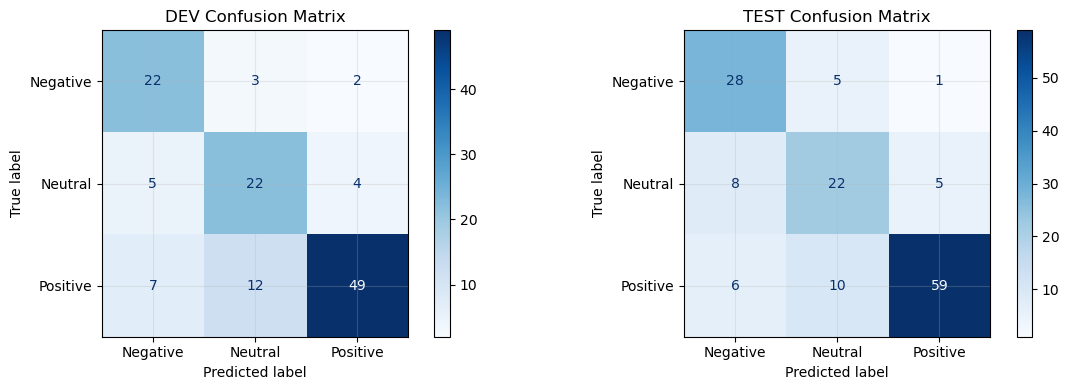

In [40]:
# ----------------------------
# Part 2.5 — Evaluate on dev/test
# ----------------------------

from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, ConfusionMatrixDisplay

LABELS = [-1, 0, 1]
LABEL_NAMES = ["Negative", "Neutral", "Positive"]

def evaluate_split(name, X, y_true):
    y_pred = mlp.predict(X)
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")

    print("\n" + "="*60)
    print(f"{name}")
    print("="*60)
    print(f"Accuracy : {acc:.4f}")
    print(f"Macro-F1 : {f1m:.4f}\n")
    print(classification_report(y_true, y_pred, labels=LABELS, target_names=LABEL_NAMES, digits=4, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    return y_pred, cm

dev_pred, dev_cm = evaluate_split("DEV", X_dev, y_dev)
test_pred, test_cm = evaluate_split("TEST", X_test, y_test)

# Plot confusion matrices (normalized)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(dev_cm, display_labels=LABEL_NAMES).plot(ax=axes[0], cmap="Blues", values_format="d")
axes[0].set_title("DEV Confusion Matrix")

ConfusionMatrixDisplay(test_cm, display_labels=LABEL_NAMES).plot(ax=axes[1], cmap="Blues", values_format="d")
axes[1].set_title("TEST Confusion Matrix")

plt.tight_layout()
plt.show()

### 2.6 Save the baseline model

We save:
- the TF‑IDF vectorizer
- the trained MLP model

This allows us to reuse the baseline later (and compare against BERT).

In [41]:
# ----------------------------
# Part 2.6 — Save baseline model
# ----------------------------

baseline_path = MODEL_DIR / "tfidf_mlp_sklearn.joblib"

joblib.dump(
    {
        "vectorizer": vec,
        "model": mlp,
        "labels": LABELS,
        "label_names": LABEL_NAMES,
        "meta": {
            "mode": MODE,
            "balanced_train": BALANCE_TRAIN,
            "train_size": int(len(train_used)),
            "dev_size": int(len(dev_df)),
            "test_size": int(len(test_df)),
            "test_macro_f1": float(f1_score(y_test, test_pred, average="macro")),
        },
    },
    baseline_path,
    compress=3,
)

print("Saved:", baseline_path)
print("File size (MB):", baseline_path.stat().st_size / 1024 / 1024)

Saved: models\notebook04_sentiment\tfidf_mlp_sklearn.joblib
File size (MB): 3.704075813293457


# Part 3 — Neural Model (PyTorch): TF‑IDF → MLP (CPU)

In Part 2 we trained a TF‑IDF baseline using scikit‑learn.
Here we train the *same idea* using PyTorch:

**TF‑IDF vectors → a small MLP classifier**

Why do this?
- It introduces the standard deep-learning workflow (Dataset → DataLoader → training loop).
- It prepares students for Transformer fine-tuning later (where training loops matter).
- We keep it **CPU-only** and minimal (students already know PyTorch).

## 3.1 Imports + Reproducibility (CPU-only)

We set seeds to make the training run reproducible.
We explicitly use CPU in this course notebook to avoid hardware variability.

python -m pip install --no-cache-dir ^
  -i https://mirror-pypi.runflare.com/simple ^
  --trusted-host mirror-pypi.runflare.com ^
  --timeout 120 --retries 10 ^
  torch torchvision torchaudio


In [42]:

%pip install torch 

Note: you may need to restart the kernel to use updated packages.


In [43]:
# Educational note:
# - CPU-only by design (no GPU branching)
# - Reproducibility seeds for numpy/random/torch

import random
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

seed_everything(SEED)

device = torch.device("cpu")
print("Torch:", torch.__version__)
print("Device:", device)

Torch: 2.12.0+cpu
Device: cpu


## 3.2 Label encoding

PyTorch `CrossEntropyLoss` expects labels in the range `0..C-1`.
Our sentiment labels are `{-1, 0, +1}`, so we map them to:

- `-1 → 0` (Negative)
- ` 0 → 1` (Neutral)
- `+1 → 2` (Positive)

In [44]:
# Educational note:
# - CrossEntropyLoss needs integer class IDs in [0, num_classes-1]

label_to_id = {-1: 0, 0: 1, 1: 2}
id_to_label = {0: "Negative", 1: "Neutral", 2: "Positive"}

y_train_id = np.array([label_to_id[int(x)] for x in y_train], dtype=np.int64)
y_dev_id   = np.array([label_to_id[int(x)] for x in y_dev], dtype=np.int64)
y_test_id  = np.array([label_to_id[int(x)] for x in y_test], dtype=np.int64)

print("Train label counts (ids):", np.bincount(y_train_id))

Train label counts (ids): [83 83 83]


## 3.3 Dataset

Our TF‑IDF matrices are SciPy **sparse**.
For a small classroom dataset, the simplest approach is:

- store sparse `X`
- convert **one row at a time** to a dense `float32` tensor inside `__getitem__`

This keeps code clean and easy to understand.

In [45]:
# - We convert one sparse row to a dense vector on-the-fly (simple + teachable)

class SparseRowDataset(Dataset):
    def __init__(self, X_sparse, y_int64):
        self.X = X_sparse
        self.y = y_int64

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx: int):
        x = self.X[idx].toarray().ravel().astype(np.float32)
        y = np.int64(self.y[idx])
        return torch.from_numpy(x), torch.tensor(y, dtype=torch.long)

## 3.4 Create datasets

We now wrap `(X_train, y_train_id)` etc. into PyTorch Datasets.

In [46]:
train_ds = SparseRowDataset(X_train, y_train_id)
dev_ds   = SparseRowDataset(X_dev, y_dev_id)
test_ds  = SparseRowDataset(X_test, y_test_id)

print("Dataset sizes:", {"train": len(train_ds), "dev": len(dev_ds), "test": len(test_ds)})

Dataset sizes: {'train': 249, 'dev': 126, 'test': 144}


## 3.5 DataLoaders

DataLoader handles:
- mini-batches
- shuffling (train only)
- iteration over the dataset

In [47]:
batch_size = 64 if MODE == "demo" else 128

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
dev_loader   = DataLoader(dev_ds, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

input_dim = X_train.shape[1]
num_classes = 3

print("input_dim:", input_dim)
print("train batches:", len(train_loader))

input_dim: 586
train batches: 4


## 3.6 Model definition (MLP)

A simple and effective baseline for TF‑IDF is a small MLP:

`Linear → ReLU → Dropout → Linear`

- Dropout reduces overfitting.
- Output layer has `num_classes=3`.

In [48]:
class MLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, dropout: float, num_classes: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        return self.net(x)

model = MLP(input_dim=input_dim, hidden_dim=256, dropout=0.2, num_classes=num_classes).to(device)
print(model)

MLP(
  (net): Sequential(
    (0): Linear(in_features=586, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=3, bias=True)
  )
)


## 3.7 Prediction helper

We define a small helper to:
- run the model on a DataLoader
- return `(y_true, y_pred)`

We keep it separate so the training loop stays clean.

In [49]:
@torch.no_grad()
def predict_loader(model: nn.Module, loader: DataLoader):
    model.eval()
    ys, ps = [], []

    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb)
        pred = torch.argmax(logits, dim=1).cpu().numpy()
        ps.append(pred)
        ys.append(yb.numpy())

    return np.concatenate(ys), np.concatenate(ps)

## 3.8 Metrics

We report:
- **Accuracy**
- **Macro-F1** (important when classes are imbalanced / Neutral is hard)

Macro-F1 averages F1 across classes equally.

In [50]:
def compute_metrics(y_true, y_pred):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro")),
    }

## 3.9 One training epoch

We implement a single-epoch function:
- forward
- loss
- backward
- optimizer step

This makes the main training loop very small.

In [51]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += float(loss.item()) * xb.size(0)

    return total_loss / len(loader.dataset)

## 3.10 Training loop (Early Stopping)

We train for a small number of epochs and stop early if DEV Macro‑F1
does not improve for `patience` epochs.

We keep the best `state_dict` in memory and restore it at the end.

In [52]:
lr = 1e-3
max_epochs = 25 if MODE == "demo" else 40
patience = 5

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

best_dev_f1 = -1.0
best_state = None
bad_epochs = 0
best_epoch = None

for epoch in range(1, max_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)

    y_dev_true, y_dev_pred = predict_loader(model, dev_loader)
    dev_metrics = compute_metrics(y_dev_true, y_dev_pred)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"dev_acc={dev_metrics['accuracy']:.4f} | "
        f"dev_macro_f1={dev_metrics['macro_f1']:.4f}"
    )

    if dev_metrics["macro_f1"] > best_dev_f1 + 1e-4:
        best_dev_f1 = dev_metrics["macro_f1"]
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print("Early stopping.")
            break

if best_state is not None:
    model.load_state_dict(best_state)

print(f"Best DEV macro-F1 = {best_dev_f1:.4f} (epoch={best_epoch})")

Epoch 01 | train_loss=1.0973 | dev_acc=0.5714 | dev_macro_f1=0.3246
Epoch 02 | train_loss=1.0794 | dev_acc=0.6429 | dev_macro_f1=0.4834
Epoch 03 | train_loss=1.0616 | dev_acc=0.7143 | dev_macro_f1=0.6146
Epoch 04 | train_loss=1.0397 | dev_acc=0.7222 | dev_macro_f1=0.6633
Epoch 05 | train_loss=1.0138 | dev_acc=0.7143 | dev_macro_f1=0.6632
Epoch 06 | train_loss=0.9814 | dev_acc=0.7222 | dev_macro_f1=0.6751
Epoch 07 | train_loss=0.9431 | dev_acc=0.7063 | dev_macro_f1=0.6665
Epoch 08 | train_loss=0.8972 | dev_acc=0.6984 | dev_macro_f1=0.6644
Epoch 09 | train_loss=0.8489 | dev_acc=0.7063 | dev_macro_f1=0.6749
Epoch 10 | train_loss=0.7944 | dev_acc=0.7222 | dev_macro_f1=0.6926
Epoch 11 | train_loss=0.7364 | dev_acc=0.7381 | dev_macro_f1=0.7147
Epoch 12 | train_loss=0.6747 | dev_acc=0.7540 | dev_macro_f1=0.7348
Epoch 13 | train_loss=0.6155 | dev_acc=0.7460 | dev_macro_f1=0.7238
Epoch 14 | train_loss=0.5592 | dev_acc=0.7460 | dev_macro_f1=0.7238
Epoch 15 | train_loss=0.5048 | dev_acc=0.7540 | 

## 3.11 TEST evaluation

After training, we evaluate once on the held-out TEST split:
- Accuracy, Macro‑F1
- per-class precision/recall/F1
- confusion matrix

In [53]:
y_test_true, y_test_pred = predict_loader(model, test_loader)
test_metrics = compute_metrics(y_test_true, y_test_pred)

print("TEST metrics:", test_metrics)
print("\nClassification report (TEST):")
print(classification_report(
    y_test_true,
    y_test_pred,
    labels=[0, 1, 2],
    target_names=[id_to_label[0], id_to_label[1], id_to_label[2]],
    digits=4,
    zero_division=0
))

print("Confusion matrix (rows=true, cols=pred):")
print(confusion_matrix(y_test_true, y_test_pred, labels=[0, 1, 2]))

TEST metrics: {'accuracy': 0.75, 'macro_f1': 0.7280567134581734}

Classification report (TEST):
              precision    recall  f1-score   support

    Negative     0.6500    0.7647    0.7027        34
     Neutral     0.5952    0.7143    0.6494        35
    Positive     0.9194    0.7600    0.8321        75

    accuracy                         0.7500       144
   macro avg     0.7215    0.7463    0.7281       144
weighted avg     0.7770    0.7500    0.7571       144

Confusion matrix (rows=true, cols=pred):
[[26  7  1]
 [ 6 25  4]
 [ 8 10 57]]


## 3.12 Save the model

We save:
- `state_dict` (model weights)
- input dimension (needed to rebuild the model later)
- label maps and basic metadata

This is enough to reload the model in a later notebook.

In [54]:
torch_path = MODEL_DIR / "tfidf_mlp_torch.pt"

torch.save(
    {
        "state_dict": model.state_dict(),
        "input_dim": int(input_dim),
        "label_to_id": label_to_id,
        "id_to_label": id_to_label,
        "meta": {
            "mode": MODE,
            "best_dev_macro_f1": float(best_dev_f1),
            "best_epoch": int(best_epoch) if best_epoch is not None else None,
            "test_accuracy": float(test_metrics["accuracy"]),
            "test_macro_f1": float(test_metrics["macro_f1"]),
            "batch_size": int(batch_size),
            "lr": float(lr),
        },
    },
    torch_path,
)

print("Saved:", torch_path)
print("File size (MB):", torch_path.stat().st_size / 1024 / 1024)

Saved: models\notebook04_sentiment\tfidf_mlp_torch.pt
File size (MB): 0.5790224075317383


# 🔎 Comparison — TF‑IDF + MLP (sklearn) vs TF‑IDF + MLP (PyTorch)


## 1) Summary Table

| Model | DEV Accuracy | DEV Macro‑F1 | TEST Accuracy | TEST Macro‑F1 |
|---|---:|---:|---:|---:|
| TF‑IDF → sklearn MLP | 0.7143 | 0.6794 | 0.7153 | 0.6794 |
| TF‑IDF → PyTorch MLP | **0.7698** | **0.7533** | **0.7431** | **0.7119** |



# Part 4 — Transformers: Fine-tuning ParsBERT for 3‑Class Sentiment (CPU)

In Parts 2–3 we used TF‑IDF models.  
In this part we move to **Transformers** and fine‑tune a Persian BERT model (**ParsBERT**) for:

**Negative / Neutral / Positive** sentiment classification.

---

## What you will learn (concepts → practice)

### 1) Transformer basics (first exposure)
You will understand the building blocks that make Transformers different from TF‑IDF:
- tokens and **subword tokenization** (why words can split into pieces)
- embeddings and why **position** matters
- **self-attention** intuition (what it computes and why it helps)
- **attention masks** (why padding must be ignored)

We will use small toy demos to make each idea concrete.

### 2) BERT basics (encoder model)
You will learn:
- what BERT is (Transformer **encoder**)
- how BERT is pretrained (Masked Language Modeling, **MLM**)
- why BERT adds special tokens like **[CLS]** and **[SEP]**
- how **[CLS]** is used as a sequence summary for classification

### 3) Hugging Face essentials (industry workflow)
You will learn:
- what the **Model Hub** is (repo_id like `HooshvareLab/bert-base-parsbert-uncased`)
- what `from_pretrained()` does (download + local cache)
- how to run **offline** using a local model folder

### 4) ParsBERT (Persian BERT)
We will:
- load the tokenizer and inspect outputs (`input_ids`, `attention_mask`)
- load a classification model and run a forward pass (logits → probabilities)
- inspect `[CLS]` and (optionally) visualize attention

### 5) Fine-tuning for sentiment (main goal)
Using the labeled splits from Part 1 (train/dev/test), we will:
- create Hugging Face Datasets
- tokenize with truncation + dynamic padding
- fine-tune ParsBERT with `Trainer`
- select the best checkpoint based on **DEV Macro‑F1**

### 6) Evaluation and saving (offline reuse)
At the end you will:
- evaluate on TEST (Accuracy + Macro‑F1 + per-class report)
- save the fine‑tuned model locally (model + tokenizer)
- reload it from disk to confirm it works offline

---

## What we will produce
A local folder like:
`models/notebook04_sentiment/parsbert_sentiment_3class/`

It contains everything needed for offline inference later.

## 4.1 Setup (CPU-only)

We keep this part CPU-only for consistent classroom runs.
We also set seeds so small demos are reproducible.

In [55]:
# Educational note:
# - CPU-only by design
# - Seeds for reproducibility across numpy / torch / transformers

import numpy as np
import torch
from transformers import set_seed

set_seed(SEED)
np.random.seed(SEED)

print("torch:", torch.__version__)

torch: 2.12.0+cpu


## 4.2 Tokens vs words (why subwords exist)

Neural NLP models do not read raw text directly.
They read **tokens**.

Modern tokenizers often use **subwords** to:
- reduce unknown words
- handle spelling variants
- keep vocabulary size manageable

First, we use a tiny *toy* subword splitter to build intuition.

In [56]:
# Educational note:
# Toy subword splitting for intuition (NOT ParsBERT).

def toy_subwords(word: str):
    if len(word) <= 4:
        return [word]
    return [word[:3], "##" + word[3:]]

for w in ["سلام", "پزشک", "تشخیص", "نوبت‌دهی", "هزینه"]:
    print(w, "->", toy_subwords(w))

سلام -> ['سلام']
پزشک -> ['پزشک']
تشخیص -> ['تشخ', '##یص']
نوبت‌دهی -> ['نوب', '##ت\u200cدهی']
هزینه -> ['هزی', '##نه']


## 4.3 Embeddings (token ids → vectors)

A model cannot process token strings.
So we map each token **id** to a vector using an embedding table:

- embedding table shape: (vocab_size, hidden_dim)
- lookup: token_id → vector

In [57]:
# Educational note:
# This shows the basic "ID -> vector" lookup used by neural NLP models.

np.random.seed(0)
vocab_size, hidden_dim = 12, 5
E = np.random.randn(vocab_size, hidden_dim)

token_ids = np.array([2, 5, 2, 9])  # a "sentence" of token IDs
X = E[token_ids]

print("token_ids:", token_ids)
print("X shape:", X.shape)  # (seq_len, hidden_dim)

token_ids: [2 5 2 9]
X shape: (4, 5)


## 4.4 Why position matters

If we only use token embeddings, the model has no built-in idea of word order.

So Transformers add **positional information**.

Two common approaches:
- sinusoidal positional encoding (classic)
- learned positional embeddings (BERT uses learned positions)

We will visualize a sinusoidal encoding just to see the idea.

In [58]:
# Educational note:
# Sinusoidal positional encoding demo (conceptual).

def sinusoidal_pos_enc(seq_len: int, dim: int):
    pe = np.zeros((seq_len, dim))
    for pos in range(seq_len):
        for i in range(0, dim, 2):
            pe[pos, i] = np.sin(pos / (10000 ** (i / dim)))
            if i + 1 < dim:
                pe[pos, i + 1] = np.cos(pos / (10000 ** (i / dim)))
    return pe

pe = sinusoidal_pos_enc(seq_len=6, dim=8)
pe.round(3)

array([[ 0.   ,  1.   ,  0.   ,  1.   ,  0.   ,  1.   ,  0.   ,  1.   ],
       [ 0.841,  0.54 ,  0.1  ,  0.995,  0.01 ,  1.   ,  0.001,  1.   ],
       [ 0.909, -0.416,  0.199,  0.98 ,  0.02 ,  1.   ,  0.002,  1.   ],
       [ 0.141, -0.99 ,  0.296,  0.955,  0.03 ,  1.   ,  0.003,  1.   ],
       [-0.757, -0.654,  0.389,  0.921,  0.04 ,  0.999,  0.004,  1.   ],
       [-0.959,  0.284,  0.479,  0.878,  0.05 ,  0.999,  0.005,  1.   ]])

## 4.5 Self-attention (the core mechanism)

Self-attention lets each token "look at" other tokens.

Given token vectors X, we compute:
- Q = XWq
- K = XWk
- V = XWv

Attention weights:
    softmax( (QKᵀ) / sqrt(d) )

Output:
    weights · V

Next: a tiny numeric attention demo (weights + output shape).

In [59]:
# Educational note:
# Tiny self-attention demo: compute attention weights and output.

def softmax(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)
    e = np.exp(x)
    return e / np.sum(e, axis=axis, keepdims=True)

np.random.seed(1)
X = np.random.randn(4, 6)
Wq, Wk, Wv = np.random.randn(6, 6), np.random.randn(6, 6), np.random.randn(6, 6)

Q, K, V = X @ Wq, X @ Wk, X @ Wv
scores = (Q @ K.T) / np.sqrt(Q.shape[-1])
A = softmax(scores, axis=-1)
Y = A @ V

print("A (attention) shape:", A.shape)
print("Y (output) shape   :", Y.shape)

A (attention) shape: (4, 4)
Y (output) shape   : (4, 6)


## 4.6 Attention masks (padding must be ignored)

When batching, we pad shorter sequences.
Padding tokens must not receive attention.

Common trick:
- set scores of padded positions to a very negative value (≈ -∞)
- softmax then makes their probability ≈ 0

In [60]:
# Educational note:
# Mask the last position as "padding".

scores = np.array([[1.0, 0.5, 0.2, 0.9]])
mask = np.array([1, 1, 1, 0])

scores_masked = scores.copy()
scores_masked[:, mask == 0] = -1e9

A = softmax(scores_masked, axis=-1)
print("masked attention:", A.round(4))

masked attention: [[0.4864 0.295  0.2186 0.    ]]


## 4.7 Encoder vs Decoder (where BERT fits)

Two common Transformer roles:

### Encoder (BERT-style)
- reads the full sequence
- outputs contextual vectors for all tokens
- great for classification and tagging

### Decoder (GPT-style)
- predicts next token autoregressively
- great for generation

BERT is an **encoder** model.

## 4.8 What is BERT?

BERT = Bidirectional Encoder Representations from Transformers.

Key idea:
- Pretrain once on huge text (learn language patterns)
- Fine-tune on your task with labeled data (sentiment here)

Main pretraining objective:
- **MLM (Masked Language Modeling)**:
  mask some tokens and predict them using both left and right context.

In [61]:
# Educational note:
# Toy MLM masking: show how an input might be "masked" during pretraining.

tokens = ["[CLS]", "دکتر", "خیلی", "خوب", "بود", "[SEP]"]
masked = tokens.copy()
masked[3] = "[MASK]"

print("original:", tokens)
print("masked  :", masked)

original: ['[CLS]', 'دکتر', 'خیلی', 'خوب', 'بود', '[SEP]']
masked  : ['[CLS]', 'دکتر', 'خیلی', '[MASK]', 'بود', '[SEP]']


## 4.9 [CLS] and [SEP] (classification recipe)

BERT input format (single sentence):
    [CLS]  tokens...  [SEP]

For classification:
- take the final hidden vector of **[CLS]** (position 0)
- feed it into a small classifier head
- output class logits (Negative/Neutral/Positive)

## 4.10 Hugging Face Hub + online/offline ParsBERT

Hugging Face Hub hosts models, identified by `repo_id`, e.g.:
- `HooshvareLab/bert-base-parsbert-uncased`

`from_pretrained()` can load from:
- Hub repo_id (online; downloads + caches)
- local folder (offline)

We will support both.

In [62]:
# Educational note:
# If ./parsbert exists -> offline; else -> online (Hub).

import os
from pathlib import Path
from transformers import AutoTokenizer

PARSBERT_REPO_ID = "HooshvareLab/bert-base-parsbert-uncased"
PARSBERT_DIR = Path("parsbert")

USE_OFFLINE = PARSBERT_DIR.exists()
SOURCE = str(PARSBERT_DIR) if USE_OFFLINE else PARSBERT_REPO_ID

print("USE_OFFLINE:", USE_OFFLINE)
print("SOURCE:", SOURCE)

USE_OFFLINE: True
SOURCE: parsbert


## 4.11 (Optional) Download ParsBERT once for offline use

Run this once when you have internet to create `./parsbert/`.
Then in class you can load everything offline.

We use `snapshot_download()` to download the repository files:
- config
- tokenizer files
- weights

In [63]:
# from huggingface_hub import snapshot_download
# snapshot_download(
#     repo_id=PARSBERT_REPO_ID,
#     local_dir="parsbert",
#     local_dir_use_symlinks=False,  # Windows-friendly
# )
# print("Downloaded to ./parsbert")

In [64]:
# Educational note:
# Prevent accidental downloads during class.

if USE_OFFLINE:
    os.environ["HF_HUB_OFFLINE"] = "1"
    print("HF_HUB_OFFLINE=1 enabled")

HF_HUB_OFFLINE=1 enabled


## 4.13 Real tokenizer (ParsBERT)

Tokenizer outputs:
- input_ids (token IDs)
- attention_mask (real tokens vs padding)

We will:
- load the tokenizer
- tokenize a Persian sentence
- inspect special tokens and subword pieces

In [65]:
tokenizer = AutoTokenizer.from_pretrained(SOURCE, local_files_only=USE_OFFLINE)

print("Tokenizer:", type(tokenizer).__name__)
print("vocab_size:", tokenizer.vocab_size)
print("special tokens:", tokenizer.special_tokens_map)

Tokenizer: BertTokenizer
vocab_size: 100000
special tokens: {'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}


In [66]:
text_demo = "دکتر خیلی خوب بود ولی زمان انتظار زیاد بود"
enc = tokenizer(text_demo)

tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"])
print("TOKENS:", tokens)
print("input_ids (first 12):", enc["input_ids"][:12])

TOKENS: ['[CLS]', 'دکتر', 'خیلی', 'خوب', 'بود', 'ولی', 'زمان', 'انتظار', 'زیاد', 'بود', '[SEP]']
input_ids (first 12): [2, 3216, 3062, 3326, 2083, 2752, 2571, 3349, 3714, 2083, 4]


## 4.15 Padding + attention_mask (real batching)

To process multiple texts together:
- we pad to the same length
- attention_mask marks padding as 0

This is exactly why attention masks exist.

In [67]:
batch = tokenizer(
    ["خیلی عالی بود", "دکتر خوب بود ولی معطلی زیاد بود"],
    padding=True,
    return_tensors="pt",
)

print("input_ids shape:", tuple(batch["input_ids"].shape))
print("attention_mask:\n", batch["attention_mask"])

input_ids shape: (2, 9)
attention_mask:
 tensor([[1, 1, 1, 1, 1, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1]])


## 4.16 ParsBERT for sequence classification

We load:
`AutoModelForSequenceClassification`

It contains:
- ParsBERT encoder
- a classification head on top (produces logits for 3 classes)

Important:
At this moment, the head is NOT fine-tuned on our sentiment dataset yet.
We are learning model I/O first.

In [68]:
from transformers import AutoConfig, AutoModelForSequenceClassification

id2label = {0: "Negative", 1: "Neutral", 2: "Positive"}
label2id = {v: k for k, v in id2label.items()}

config = AutoConfig.from_pretrained(
    SOURCE,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
    local_files_only=USE_OFFLINE,
)

model = AutoModelForSequenceClassification.from_pretrained(
    SOURCE,
    config=config,
    local_files_only=USE_OFFLINE,
).to("cpu")

print("Model:", type(model).__name__)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: parsbert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initi

Model: BertForSequenceClassification


## 4.16A Why do we see "MISSING" and "UNEXPECTED" weights?

When we load `BertForSequenceClassification` from a pretrained BERT checkpoint:

- **UNEXPECTED** weights usually belong to the *pretraining heads* (MLM / NSP),
  which are not used in sequence classification.
- **MISSING** weights are typically the new **classifier head** parameters
  (they do not exist in the pretrained checkpoint), so they are randomly initialized.

This is expected. Fine-tuning will learn the classifier head on our sentiment labels.

## 4.17 Forward pass (logits → probabilities)

The model returns logits:
- shape: (batch_size, num_labels)

We apply softmax to convert logits into probabilities.

In [69]:
import torch.nn.functional as F
import torch

x = tokenizer([text_demo], return_tensors="pt")

with torch.no_grad():
    out = model(**x)
    probs = F.softmax(out.logits, dim=-1)[0].numpy()

print("logits shape:", tuple(out.logits.shape))
print("probs:", probs.round(4))
print("pred:", id2label[int(probs.argmax())])

logits shape: (1, 3)
probs: [0.2729 0.4689 0.2582]
pred: Neutral


## 4.18 Inspect the [CLS] vector

We ask the model for hidden states:
- last hidden state shape: (B, T, H)
- [CLS] vector is position 0: (B, H)

This is the sequence summary used for classification.

In [70]:
with torch.no_grad():
    out_h = model(**x, output_hidden_states=True)
    last_hidden = out_h.hidden_states[-1]
    cls_vec = last_hidden[:, 0, :]

print("last_hidden:", tuple(last_hidden.shape))
print("cls_vec    :", tuple(cls_vec.shape))

last_hidden: (1, 11, 768)
cls_vec    : (1, 768)


## 4.18A BERT embeddings = Word + Position + TokenType

In BERT, the input embedding of each token is built by **adding**:

- **Word embedding**  (what token is it?)
- **Position embedding** (where is it in the sequence?)
- **Token type embedding** (which segment? sentence A/B)

Then BERT applies LayerNorm (and dropout during training).

This means: even if the same token appears twice, it can have **different embeddings** because its **position** is different.

In [88]:
# Educational note:
# We inspect the *learned* embeddings inside ParsBERT:
# word_embeddings + position_embeddings + token_type_embeddings

import torch

model.eval()
base = model.bert
emb_layer = base.embeddings

input_ids = x["input_ids"]
token_type_ids = x.get("token_type_ids", torch.zeros_like(input_ids))

B, T = input_ids.shape
position_ids = torch.arange(T).unsqueeze(0)

word_emb = emb_layer.word_embeddings(input_ids)                 # (B,T,H)
pos_emb  = emb_layer.position_embeddings(position_ids)          # (1,T,H)
type_emb = emb_layer.token_type_embeddings(token_type_ids)      # (B,T,H)

print("word_emb:", tuple(word_emb.shape))
print("pos_emb :", tuple(pos_emb.shape))
print("type_emb:", tuple(type_emb.shape))

word_emb: (1, 11, 768)
pos_emb : (1, 11, 768)
type_emb: (1, 11, 768)


## 4.18B Same token ≠ same embedding (because of position)

We find repeated tokens in the sentence (if any),
then show:

- their **word embedding** vectors are identical (same token id)
- but their **final input embedding** differs after adding position embedding

In [89]:
# Educational note:
# We compare embeddings for a repeated token (e.g., "بود" appears twice in your demo sentence).

tokens_demo = tokenizer.convert_ids_to_tokens(input_ids[0].tolist())

# find a token that repeats (first repeated token)
from collections import Counter
cnt = Counter(tokens_demo)
rep_tok = next((t for t, c in cnt.items() if c >= 2 and t not in ["[CLS]", "[SEP]"]), None)

print("Tokens:", tokens_demo)
print("Repeated token chosen:", rep_tok)

idxs = [i for i, t in enumerate(tokens_demo) if t == rep_tok]
i1, i2 = idxs[0], idxs[1]

final_inp = emb_layer.LayerNorm(word_emb + pos_emb + type_emb)  # dropout disabled in eval()

d_word  = torch.norm(word_emb[0, i1] - word_emb[0, i2]).item()
d_final = torch.norm(final_inp[0, i1] - final_inp[0, i2]).item()

print("L2 distance (word embedding only) :", round(d_word, 6))
print("L2 distance (word+pos+type, LN)   :", round(d_final, 6))

Tokens: ['[CLS]', 'دکتر', 'خیلی', 'خوب', 'بود', 'ولی', 'زمان', 'انتظار', 'زیاد', 'بود', '[SEP]']
Repeated token chosen: بود
L2 distance (word embedding only) : 0.0
L2 distance (word+pos+type, LN)   : 10.750198


## 4.18C Q, K, V inside BERT (real weights, real sentence)

In self-attention, each token builds a new representation.

For each token embedding `h`:
- **Q = h Wq**  (what am I looking for?)
- **K = h Wk**  (what do I contain / offer?)
- **V = h Wv**  (what information do I pass if attended to?)

Attention weights for token *i* come from comparing `Qi` with all `Kj`.

Now we compute Q/K/V using the actual parameters of **ParsBERT layer 0**.

In [95]:
# Educational note:
# - We compute Q, K, V from the real weights of ParsBERT layer 0.
# - We wrap everything in torch.no_grad() to avoid autograd warnings.

import math
import torch

model.eval()
base = model.bert
emb_layer = base.embeddings

input_ids = x["input_ids"]
token_type_ids = x.get("token_type_ids", torch.zeros_like(input_ids))

with torch.no_grad():
    layer0 = base.encoder.layer[0].attention.self
    H = layer0.num_attention_heads
    D = layer0.attention_head_size

    emb_out = emb_layer(input_ids=input_ids, token_type_ids=token_type_ids)  # (B,T,768)

    Q = layer0.query(emb_out)   # (B,T,H*D)
    K = layer0.key(emb_out)
    V = layer0.value(emb_out)

B, T = input_ids.shape

def split_heads(z):
    return z.view(B, T, H, D).permute(0, 2, 1, 3)  # (B,H,T,D)

Qh, Kh, Vh = split_heads(Q), split_heads(K), split_heads(V)
print("Qh/Kh/Vh:", tuple(Qh.shape), tuple(Kh.shape), tuple(Vh.shape))

Qh/Kh/Vh: (1, 12, 11, 64) (1, 12, 11, 64) (1, 12, 11, 64)


## 4.18D Attention weights (with mask)

For each head:
- scores: `Qh @ Khᵀ / sqrt(D)`
- apply padding mask (so padding gets ~0 attention)
- softmax over the last dimension

Result:
`attn[h, i, j]` = how much token i attends to token j (for one head).

In [96]:
# Educational note:
# - Compute attention weights: softmax(QK^T / sqrt(D))
# - Apply attention_mask so padding gets ~0 probability.

with torch.no_grad():
    mask = x["attention_mask"].unsqueeze(1).unsqueeze(2)  # (B,1,1,T)

    scores = (Qh @ Kh.transpose(-1, -2)) / math.sqrt(D)   # (B,H,T,T)
    scores = scores.masked_fill(mask == 0, -1e9)

    attn = torch.softmax(scores, dim=-1)                  # (B,H,T,T)

print("attn shape:", tuple(attn.shape))
print("Row sum (head0, token0):", float(attn[0, 0, 0].sum().detach().cpu()))

attn shape: (1, 12, 11, 11)
Row sum (head0, token0): 1.0


## 4.18E Attention visualization

Matplotlib does not handle Persian RTL shaping well without extra font/RTL setup.
So we visualize attention using **token indices** instead.

We print a legend (index → token) as text,
and draw the heatmap using only indices.

In [99]:
# Educational note:
# Index → token legend (works perfectly in plain text).

tokens_demo = tokenizer.convert_ids_to_tokens(input_ids[0].tolist())
for i, t in enumerate(tokens_demo):
    print(f"{i:02d}: {t}")

00: [CLS]
01: دکتر
02: خیلی
03: خوب
04: بود
05: ولی
06: زمان
07: انتظار
08: زیاد
09: بود
10: [SEP]


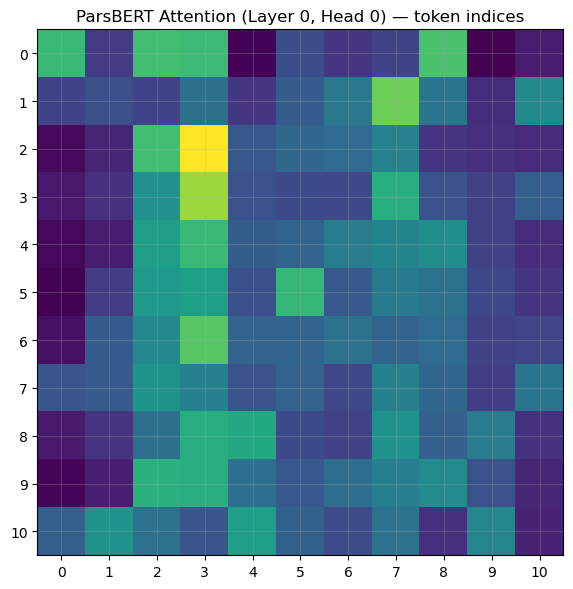

In [100]:
import matplotlib.pyplot as plt
import numpy as np

T_show = min(T, 18)
A0 = attn[0, 0, :T_show, :T_show].detach().cpu().numpy()

plt.figure(figsize=(7, 6))
plt.imshow(A0, cmap="viridis")
plt.xticks(range(T_show), [str(i) for i in range(T_show)], rotation=0)
plt.yticks(range(T_show), [str(i) for i in range(T_show)])
plt.title("ParsBERT Attention (Layer 0, Head 0) — token indices")
plt.tight_layout()
plt.show()

## 4.18F Context vector = weighted sum of V

This is the key intuition:
For a fixed head and a fixed token i,

`context_i = sum_j  attn[i, j] * V[j]`

So token i literally mixes information from other tokens based on attention weights.

In [101]:
# Educational note:
# Compute the context vector for ONE token:
# context_i = sum_j attn[i,j] * V[j]
# and print the top contributing tokens.

tokens_demo = tokenizer.convert_ids_to_tokens(input_ids[0].tolist())

head = 0
i = min(7, T - 1)   # pick a query token index
w = attn[0, head, i]  # (T,)

top = torch.topk(w, k=min(6, T)).indices.tolist()

print("Query token:", i, tokens_demo[i])
print("Top attended tokens (head 0):")
for j in top:
    print(f"  {j:02d}  token={tokens_demo[j]:>6}  weight={float(w[j]):.4f}")

context_i = (w.unsqueeze(-1) * Vh[0, head]).sum(dim=0)  # (D,)
print("context_i shape:", tuple(context_i.shape))
print("context_i norm :", float(torch.norm(context_i)))

Query token: 7 انتظار
Top attended tokens (head 0):
  02  token=  خیلی  weight=0.1388
  07  token=انتظار  weight=0.1193
  03  token=   خوب  weight=0.1185
  10  token= [SEP]  weight=0.1061
  08  token=  زیاد  weight=0.0905
  05  token=   ولی  weight=0.0873
context_i shape: (64,)
context_i norm : 2.0845048427581787


## 4.18G Different heads can focus on different patterns

Multi-head attention means:
- each head can learn a different "view" of the sentence

We compare top attended tokens for two different heads.

In [102]:
# Educational note:
# Compare two heads for the SAME query token index.

tokens_demo = tokenizer.convert_ids_to_tokens(input_ids[0].tolist())
i = min(7, T - 1)

def top_tokens_for(head, i, k=6):
    w = attn[0, head, i]
    top = torch.topk(w, k=min(k, T)).indices.tolist()
    return [(j, tokens_demo[j], float(w[j])) for j in top]

for h in [0, 1]:
    print("\nHead", h, "| query:", i, tokens_demo[i])
    for j, t, wj in top_tokens_for(h, i, k=6):
        print(f"  {j:02d}  {t:>6}  {wj:.4f}")


Head 0 | query: 7 انتظار
  02    خیلی  0.1388
  07  انتظار  0.1193
  03     خوب  0.1185
  10   [SEP]  0.1061
  08    زیاد  0.0905
  05     ولی  0.0873

Head 1 | query: 7 انتظار
  00   [CLS]  0.1773
  09     بود  0.1228
  04     بود  0.1110
  10   [SEP]  0.0966
  08    زیاد  0.0865
  06    زمان  0.0723


## 4.19 Fine-tuning plan

Now that we understand the model I/O, we fine-tune ParsBERT on our labeled dataset.

High-level pipeline:
1) Build a Hugging Face `Dataset` from (train/dev/test)
2) Tokenize with truncation (+ dynamic padding)
3) Train with `Trainer` (evaluate on DEV each epoch)
4) Pick the best checkpoint by DEV **Macro‑F1**
5) Evaluate once on TEST
6) Save the fine-tuned model + tokenizer for offline reuse

## 4.20 Dependencies (only if missing)

If your environment does not have these packages, install them once:
- transformers
- datasets
- huggingface_hub
- safetensors

In [71]:
# %pip install -U transformers datasets huggingface_hub safetensors

## 4.21 Data splits

We reuse the grouped (doctor_id) splits produced earlier:
- `train_df`, `dev_df`, `test_df`

We fine-tune on TRAIN, select the best model using DEV, and report final metrics on TEST.

In [72]:
# Educational note:
# Quick sanity checks (small and safe).

assert "text" in train_df.columns and "label_int" in train_df.columns
assert set(train_df["label_int"].unique()).issubset({-1, 0, 1})
print("Splits OK:", len(train_df), len(dev_df), len(test_df))

Splits OK: 434 126 144


## 4.22 (Optional) Balance/cap TRAIN

In small datasets, sentiment is often imbalanced (many Positives).
Balancing TRAIN can make learning more stable (especially for Neutral).

Important:
- We only modify TRAIN
- DEV and TEST stay unchanged

In [73]:
# Educational note:
# Balance TRAIN by sampling the same number per class (optionally capped).

import pandas as pd

CAP_PER_CLASS = 120 if MODE == "demo" else None

def balance_train(df_in: pd.DataFrame, cap_per_class=None, seed=42):
    counts = df_in["label_int"].value_counts()
    n = int(counts.min()) if cap_per_class is None else min(int(counts.min()), int(cap_per_class))
    parts = [df_in[df_in["label_int"] == c].sample(n=n, random_state=seed) for c in sorted(counts.index)]
    return pd.concat(parts, ignore_index=True).sample(frac=1.0, random_state=seed).reset_index(drop=True)

train_for_bert = balance_train(train_df, cap_per_class=CAP_PER_CLASS, seed=SEED)
print("train_for_bert size:", len(train_for_bert))
print(train_for_bert["label_int"].value_counts().sort_index())

train_for_bert size: 249
label_int
-1    83
 0    83
 1    83
Name: count, dtype: int64


## 4.23 Hugging Face `Dataset`

Trainer works nicely with `datasets.Dataset`.
We create a minimal dataset with:
- `text`
- `labels` (0/1/2)

Label mapping:
- -1 → 0 (Negative)
-  0 → 1 (Neutral)
- +1 → 2 (Positive)

In [74]:
from datasets import Dataset

label_to_id = {-1: 0, 0: 1, 1: 2}

def to_hf_dataset(df_in: pd.DataFrame) -> Dataset:
    d = pd.DataFrame({
        "text": df_in["text"].astype(str).str.replace("\u200c", " ").str.strip(),
        "labels": df_in["label_int"].astype(int).map(label_to_id).astype(int),
    })
    return Dataset.from_pandas(d, preserve_index=False)

ds_train = to_hf_dataset(train_for_bert)
ds_dev   = to_hf_dataset(dev_df)
ds_test  = to_hf_dataset(test_df)

print("HF Dataset sizes:", len(ds_train), len(ds_dev), len(ds_test))

HF Dataset sizes: 249 126 144


## 4.24 Tokenization for training

We tokenize with:
- truncation=True
- max_length (smaller in demo mode)

We do **not** pad inside the tokenizer call here.
Padding will be done dynamically per batch using a data collator.

In [75]:
MAX_LEN = 128 if MODE == "demo" else 192

def tok(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)

print("MAX_LEN:", MAX_LEN)

MAX_LEN: 128


## 4.25 Apply tokenization with `map`

`Dataset.map()` applies our tokenization function efficiently.

We remove the raw `text` column after tokenization to keep the training dataset clean.

In [76]:
ds_train_tok = ds_train.map(tok, batched=True, remove_columns=["text"])
ds_dev_tok   = ds_dev.map(tok, batched=True, remove_columns=["text"])
ds_test_tok  = ds_test.map(tok, batched=True, remove_columns=["text"])

print("Tokenized columns:", ds_train_tok.column_names)

Map:   0%|          | 0/249 [00:00<?, ? examples/s]

Map:   0%|          | 0/126 [00:00<?, ? examples/s]

Map:   0%|          | 0/144 [00:00<?, ? examples/s]

Tokenized columns: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']


## 4.26 Dynamic padding

In each batch, sequences have different lengths.
Dynamic padding pads only up to the longest sequence in that batch.

This is usually faster and simpler than padding everything to MAX_LEN.

In [77]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("Data collator ready")

Data collator ready


## 4.27 Metrics

We use:
- Accuracy
- Macro‑F1 (important because Neutral is typically harder)

Trainer expects `compute_metrics(eval_pred)`.

In [78]:
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
    }

## 4.28 TrainingArguments (CPU-only)

Key settings:
- evaluate each epoch
- save each epoch
- load best model at end using DEV macro‑F1
- disable external logging (`report_to="none"`)
- force CPU (`no_cuda=True`)

In [79]:
from transformers import TrainingArguments
from pathlib import Path

RUN_DIR = Path(MODEL_DIR) / "parsbert_sentiment_run"
RUN_DIR.mkdir(parents=True, exist_ok=True)

num_epochs = 2 if MODE == "demo" else 3
train_bs   = 8 if MODE == "demo" else 16
eval_bs    = 16

print("epochs/train_bs:", num_epochs, train_bs)

epochs/train_bs: 2 8


In [80]:
# Educational note:
# - transformers APIs change across versions.
# - We build TrainingArguments using only the parameters supported by THIS version.

import inspect
import transformers
from transformers import TrainingArguments

print("transformers:", transformers.__version__)

sig = inspect.signature(TrainingArguments.__init__).parameters

args = dict(
    output_dir=str(RUN_DIR),
    learning_rate=2e-5,
    per_device_train_batch_size=train_bs,
    per_device_eval_batch_size=eval_bs,
    num_train_epochs=num_epochs,
    weight_decay=0.01,
    logging_steps=20,
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    report_to="none",
    seed=SEED,
)

# evaluation strategy key changed in v5
if "eval_strategy" in sig:
    args["eval_strategy"] = "epoch"
elif "evaluation_strategy" in sig:
    args["evaluation_strategy"] = "epoch"

# CPU-only key changed across versions
if "use_cpu" in sig:
    args["use_cpu"] = True
elif "no_cuda" in sig:
    args["no_cuda"] = True

# keep only supported args (prevents unexpected keyword errors)
args = {k: v for k, v in args.items() if k in sig}

training_args = TrainingArguments(**args)
print("TrainingArguments ready.")

transformers: 5.8.1
TrainingArguments ready.


## 4.30 Trainer (why we use it)

Trainer is a training engine that handles:
- batching + dynamic padding (via collator)
- forward/backward + optimizer steps
- evaluation loops
- checkpoint saving
- selecting the best checkpoint by a chosen metric

This lets us focus on NLP decisions instead of training boilerplate.

In [81]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds_train_tok,
    eval_dataset=ds_dev_tok,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Trainer ready")

Trainer ready


## 4.31 Fine-tune ParsBERT

This is the main training step.
We train on TRAIN and evaluate on DEV each epoch.
The best checkpoint (by DEV macro‑F1) is loaded automatically at the end.

In [82]:
trainer.train()
print("Training finished")

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.965218,0.619726,0.833333,0.809054
2,0.535702,0.532969,0.857143,0.844512


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training finished


## 4.32 Evaluate on TEST

We evaluate once on the held-out TEST split and report:
- test metrics (accuracy, macro‑F1)
- per-class precision/recall/F1

In [83]:
pred = trainer.predict(ds_test_tok)
print("TEST metrics:", {k: v for k, v in pred.metrics.items() if "test_" in k})

TEST metrics: {'test_loss': 0.6062047481536865, 'test_accuracy': 0.7777777777777778, 'test_macro_f1': 0.7600951880165567, 'test_runtime': 9.0971, 'test_samples_per_second': 15.829, 'test_steps_per_second': 0.989}


In [84]:
from sklearn.metrics import classification_report

y_true = pred.label_ids
y_pred = np.argmax(pred.predictions, axis=1)

print(classification_report(
    y_true, y_pred,
    labels=[0, 1, 2],
    target_names=[id2label[0], id2label[1], id2label[2]],
    digits=4,
    zero_division=0,
))

              precision    recall  f1-score   support

    Negative     0.6842    0.7647    0.7222        34
     Neutral     0.6170    0.8286    0.7073        35
    Positive     0.9661    0.7600    0.8507        75

    accuracy                         0.7778       144
   macro avg     0.7558    0.7844    0.7601       144
weighted avg     0.8147    0.7778    0.7855       144



## 4.34 Save the fine-tuned model

We save:
- model weights + config
- tokenizer files

After saving, we can reload fully offline from the saved folder.

In [85]:
SAVE_DIR = Path(MODEL_DIR) / "parsbert_sentiment_3class"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

trainer.save_model(str(SAVE_DIR))
tokenizer.save_pretrained(str(SAVE_DIR))

print("Saved to:", SAVE_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: models\notebook04_sentiment\parsbert_sentiment_3class


## 4.35 Reload sanity check (offline)

We reload the saved model folder from disk.
This confirms our saved artifact is complete and reusable.

In [86]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tok2 = AutoTokenizer.from_pretrained(SAVE_DIR, local_files_only=True)
mod2 = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR, local_files_only=True).to("cpu")

print("Reload OK:", type(mod2).__name__)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Reload OK: BertForSequenceClassification


## 4.36 Quick inference demo

We run a few Persian examples through the fine-tuned model and print:
- probabilities
- predicted label

This is the same logic we will reuse later (e.g., ABSA snippets).

In [87]:
import torch.nn.functional as F
import torch
import numpy as np

samples = [
    "واقعا عالی بود و خیلی راضی هستم",
    "بد برخورد بودند و اصلا توصیه نمی‌کنم",
    "معاینه انجام شد و دارو نوشتند",
]

batch2 = tok2(samples, padding=True, truncation=True, max_length=128, return_tensors="pt")
with torch.no_grad():
    logits = mod2(**batch2).logits
    probs = F.softmax(logits, dim=-1).cpu().numpy()
    preds = probs.argmax(axis=1)

for s, p, pred_id in zip(samples, probs, preds):
    print("-", s)
    print("  probs:", np.round(p, 4), "| pred:", id2label[int(pred_id)])

- واقعا عالی بود و خیلی راضی هستم
  probs: [0.1099 0.1536 0.7365] | pred: Positive
- بد برخورد بودند و اصلا توصیه نمی‌کنم
  probs: [0.3329 0.4233 0.2438] | pred: Neutral
- معاینه انجام شد و دارو نوشتند
  probs: [0.15   0.5731 0.2769] | pred: Neutral
